In [1]:
# ==========================================================
# Notebook 4
# Dataset Preparation
# ==========================================================

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import zarr

from scipy.ndimage import gaussian_filter

import torch
from torch.utils.data import Dataset, DataLoader

plt.style.use("ggplot")

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PATCH_Z = 16
PATCH_Y = 128
PATCH_X = 128

PATCH_SIZE = (
    PATCH_Z,
    PATCH_Y,
    PATCH_X
)

HALF_Z = PATCH_Z // 2
HALF_Y = PATCH_Y // 2
HALF_X = PATCH_X // 2

SIGMA_XY = 3
SIGMA_Z = 1.5

BATCH_SIZE = 2

NUM_WORKERS = 2

In [3]:
DATASET = Path(
    "/kaggle/input/competitions/biohub-cell-tracking-during-development"
)

TRAIN = DATASET / "train"

zarr_files = sorted(
    TRAIN.glob("*.zarr")
)

print("Training Volumes:", len(zarr_files))

Training Volumes: 199


In [4]:
def read_nodes(geff_file):

    gt = zarr.open(
        geff_file,
        mode="r"
    )

    nodes = pd.DataFrame({

        "t": np.array(
            gt["nodes"]["props"]["t"]["values"]
        ),

        "z": np.array(
            gt["nodes"]["props"]["z"]["values"]
        ),

        "y": np.array(
            gt["nodes"]["props"]["y"]["values"]
        ),

        "x": np.array(
            gt["nodes"]["props"]["x"]["values"]
        )

    })

    return nodes

In [5]:
def normalize(volume):

    volume = volume.astype(np.float32)

    volume -= volume.min()

    volume /= volume.max() + 1e-8

    return volume

In [6]:
def pad_volume(volume):

    return np.pad(

        volume,

        (

            (HALF_Z, HALF_Z),

            (HALF_Y, HALF_Y),

            (HALF_X, HALF_X)

        ),

        mode="constant"

    )

In [7]:
def extract_patch(volume, center):

    padded = pad_volume(volume)

    z, y, x = center

    z += HALF_Z
    y += HALF_Y
    x += HALF_X

    patch = padded[

        z-HALF_Z:z+HALF_Z,

        y-HALF_Y:y+HALF_Y,

        x-HALF_X:x+HALF_X

    ]

    return patch

In [8]:
samples = []

for file in zarr_files:

    nodes = read_nodes(
        file.with_suffix(".geff")
    )

    for _, row in nodes.iterrows():

        samples.append({

            "file": file,

            "t": int(row.t),

            "z": int(row.z),

            "y": int(row.y),

            "x": int(row.x)

        })

print("Training Samples:", len(samples))

Training Samples: 133318


In [9]:
from scipy.ndimage import gaussian_filter

def create_heatmap():

    heat = np.zeros(PATCH_SIZE, dtype=np.float32)

    heat[
        HALF_Z,
        HALF_Y,
        HALF_X
    ] = 1.0

    heat = gaussian_filter(
        heat,
        sigma=(1.5, 3.0, 3.0)
    )

    heat /= heat.max()

    return heat

TARGET = create_heatmap()

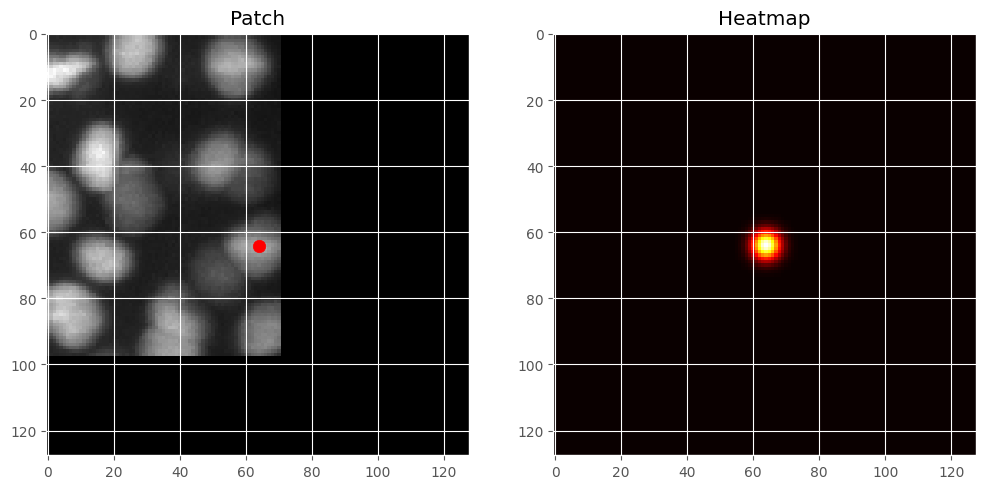

In [10]:
sample = samples[0]

volume = zarr.open(
    sample["file"],
    mode="r"
)["0"]

frame = normalize(
    volume[sample["t"]]
)

patch = extract_patch(

    frame,

    (

        sample["z"],

        sample["y"],

        sample["x"]

    )

)

fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].imshow(
    patch.max(axis=0),
    cmap="gray"
)

ax[0].scatter(
    HALF_X,
    HALF_Y,
    c="red",
    s=80
)

ax[0].set_title("Patch")

ax[1].imshow(
    TARGET.max(axis=0),
    cmap="hot"
)

ax[1].set_title("Heatmap")

plt.show()

In [11]:
# ==========================================================
# Dataset Quality Check
# ==========================================================

distances = []

for idx in np.random.choice(len(samples), 50, replace=False):

    sample = samples[idx]

    volume = zarr.open(sample["file"], mode="r")["0"]

    frame = normalize(volume[sample["t"]])

    patch = extract_patch(
        frame,
        (sample["z"], sample["y"], sample["x"])
    )

    mip = patch.max(axis=0)

    # Brightest pixel in the MIP
    py, px = np.unravel_index(np.argmax(mip), mip.shape)

    distance = np.sqrt(
        (py - HALF_Y) ** 2 +
        (px - HALF_X) ** 2
    )

    distances.append(distance)

print(f"Average offset : {np.mean(distances):.2f} pixels")
print(f"Maximum offset : {np.max(distances):.2f} pixels")

Average offset : 50.42 pixels
Maximum offset : 89.81 pixels


In [12]:
def verify_patch(sample):

    volume = zarr.open(sample["file"], mode="r")["0"]

    frame = normalize(volume[sample["t"]])

    patch = extract_patch(
        frame,
        (
            sample["z"],
            sample["y"],
            sample["x"]
        )
    )

    # Coordinates of the annotation within the patch
    center = (HALF_Y, HALF_X)

    plt.figure(figsize=(7,7))

    plt.imshow(
        patch.max(axis=0),
        cmap="gray"
    )

    plt.scatter(
        center[1],
        center[0],
        s=150,
        c="red",
        marker="+",
        linewidths=2
    )

    plt.title("Annotation Location")
    plt.show()

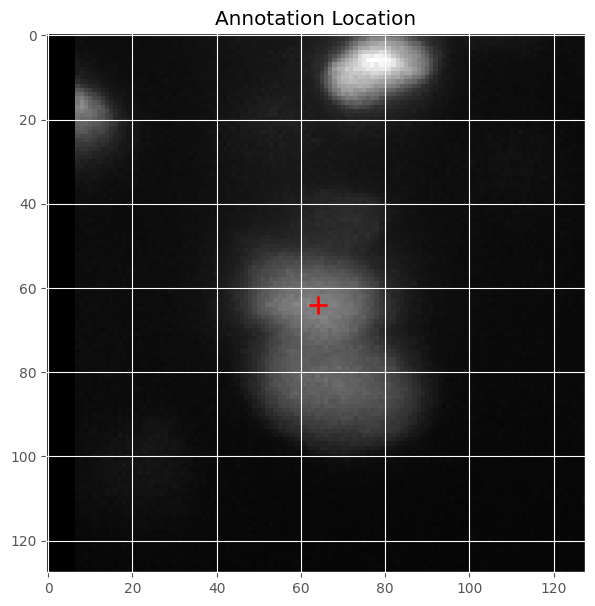

In [13]:
verify_patch(samples[np.random.randint(len(samples))])

In [14]:
for sample in random.sample(samples, 20):

    patch = extract_patch(
        normalize(
            zarr.open(sample["file"], mode="r")["0"][sample["t"]]
        ),
        (
            sample["z"],
            sample["y"],
            sample["x"]
        )
    )

    assert patch.shape == PATCH_SIZE

In [15]:
# ==========================================================
# Data Augmentation
# ==========================================================

def augment(image, target):

    # Horizontal flip
    if random.random() < 0.5:
        image = np.flip(image, axis=2).copy()
        target = np.flip(target, axis=2).copy()

    # Vertical flip
    if random.random() < 0.5:
        image = np.flip(image, axis=1).copy()
        target = np.flip(target, axis=1).copy()

    # Random 90° rotation
    k = random.randint(0, 3)

    image = np.rot90(image, k, axes=(1, 2)).copy()
    target = np.rot90(target, k, axes=(1, 2)).copy()

    # Brightness
    image *= np.random.uniform(0.95, 1.05)

    # Gaussian noise
    image += np.random.normal(
        0,
        0.01,
        image.shape
    )

    image = np.clip(image, 0, 1)

    return image, target

In [16]:
# ==========================================================
# Cell Dataset
# ==========================================================

class CellDataset(Dataset):

    def __init__(self, samples, training=True):

        self.samples = samples
        self.training = training

        self.current_file = None
        self.current_volume = None

    def __len__(self):

        return len(self.samples)

    def _get_volume(self, file):

        if self.current_file != file:

            self.current_file = file

            self.current_volume = zarr.open(
                file,
                mode="r"
            )["0"]

        return self.current_volume

    def __getitem__(self, idx):

        sample = self.samples[idx]

        volume = self._get_volume(
            sample["file"]
        )

        frame = normalize(
            volume[sample["t"]]
        )

        patch = extract_patch(
            frame,
            (
                sample["z"],
                sample["y"],
                sample["x"]
            )
        )

        target = TARGET.copy()

        if self.training:

            patch, target = augment(
                patch,
                target
            )

        patch = torch.from_numpy(
            patch
        ).unsqueeze(0)

        target = torch.from_numpy(
            target
        ).unsqueeze(0)

        return patch.float(), target.float()

In [17]:
dataset = CellDataset(
    samples,
    training=True
)

loader = DataLoader(

    dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available(),

    persistent_workers=NUM_WORKERS > 0
)

print(len(dataset))

133318


In [18]:
images, targets = next(iter(loader))

print(images.shape)
print(targets.shape)

print(images.min(), images.max())
print(targets.min(), targets.max())

torch.Size([2, 1, 16, 128, 128])
torch.Size([2, 1, 16, 128, 128])
tensor(0.) tensor(0.6862)
tensor(0.) tensor(1.)


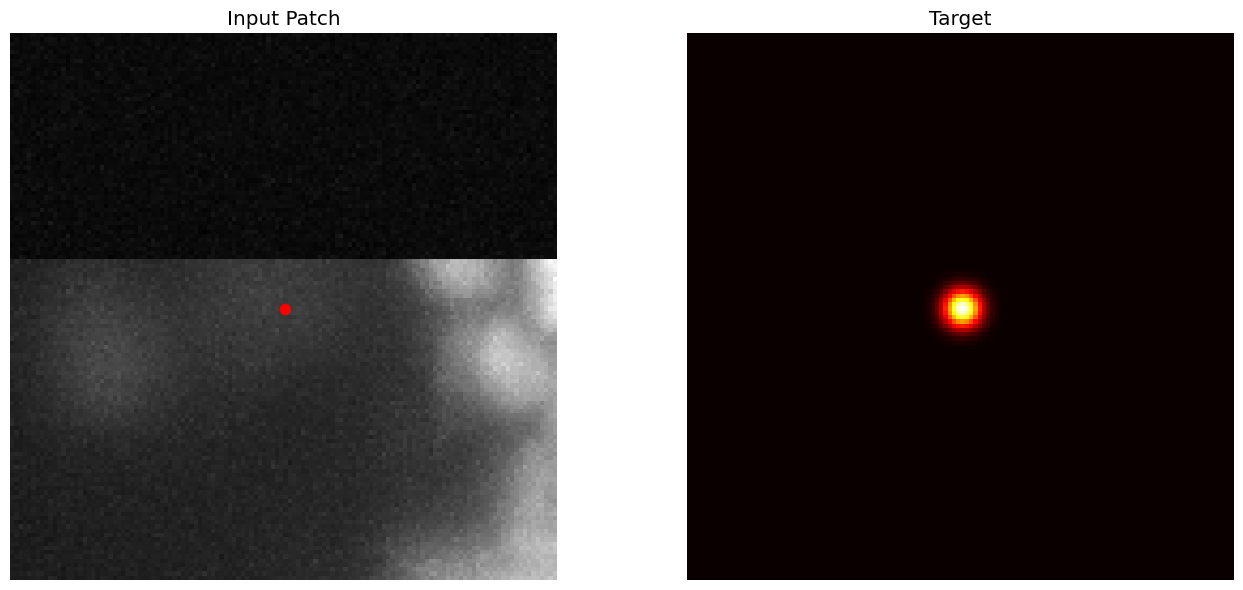

In [19]:
image = images[0,0].numpy()

target = targets[0,0].numpy()

mip = image.max(axis=0)

hm = target.max(axis=0)

fig, ax = plt.subplots(1,2, figsize=(14,6))

ax[0].imshow(
    mip,
    cmap="gray"
)

ax[0].scatter(
    HALF_X,
    HALF_Y,
    c="red",
    s=60
)

ax[0].set_title("Input Patch")

ax[1].imshow(
    hm,
    cmap="hot"
)

ax[1].set_title("Target")

for a in ax:
    a.axis("off")

plt.tight_layout()

plt.show()

In [20]:
for _ in range(20):

    idx = random.randint(0, len(dataset)-1)

    patch, target = dataset[idx]

    assert patch.shape == (1, PATCH_Z, PATCH_Y, PATCH_X)
    assert target.shape == (1, PATCH_Z, PATCH_Y, PATCH_X)

    assert torch.isfinite(patch).all()
    assert torch.isfinite(target).all()

    assert patch.min() >= 0
    assert patch.max() <= 1

    assert target.min() >= 0
    assert target.max() <= 1

print("✓ Dataset sanity check passed")

✓ Dataset sanity check passed
